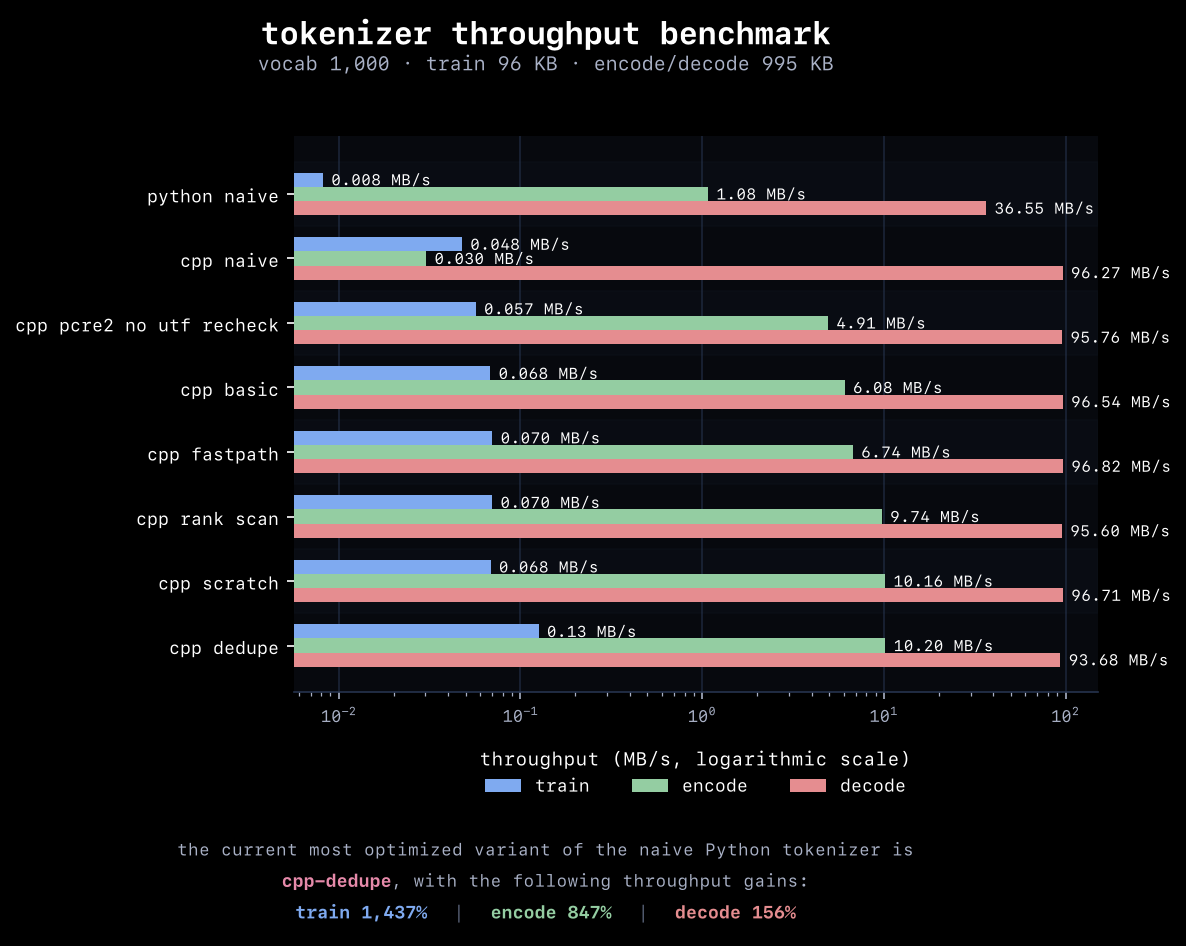

In [7]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, VPacker

background = "#000000"
panel = "#07090E"
text = "#FFFFFF"
muted = "#A9B1C6"
grid = "#26334D"
separator = "#5A647A"

colors = {
    "train": "#7FAAF0",
    "encode": "#94CDA2",
    "decode": "#E58D90",
}

plt.rcParams.update({
    "font.family": "monospace",
    "font.monospace": ["SF Mono", "Menlo", "DejaVu Sans Mono"],
    "figure.facecolor": background,
    "axes.facecolor": panel,
    "axes.edgecolor": muted,
    "axes.labelcolor": text,
    "xtick.color": muted,
    "ytick.color": text,
    "text.color": text,
})

records = [
    json.loads(line)
    for line in Path("benchmarks.jsonl").read_text().splitlines()
    if line.strip()
]

latest = {
    (record["label"], record["operation"]): record
    for record in records
}

operations = ["train", "encode", "decode"]
implementations = list(dict.fromkeys(record["label"] for record in records))

implementations = [
    name
    for name in implementations
    if all((name, operation) in latest for operation in operations)
]

python_label = "python-naive"
optimized_label = implementations[-1]

speeds_by_operation = {
    operation: [
        latest[(name, operation)]["median_throughput_bytes_per_second"] / 1_000_000
        for name in implementations
    ]
    for operation in operations
}

gains = {
    operation: (
        latest[(optimized_label, operation)]["median_throughput_bytes_per_second"]
        / latest[(python_label, operation)]["median_throughput_bytes_per_second"]
        - 1
    ) * 100
    for operation in operations
}


def format_speed(speed):
    if speed >= 1000:
        return f"{speed / 1000:.2f} GB/s"
    if speed < 0.1:
        return f"{speed:.3f} MB/s"
    return f"{speed:.2f} MB/s"


def caption_text(value, color=muted, weight="normal", size=9):
    return TextArea(
        value,
        textprops={
            "color": color,
            "fontsize": size,
            "fontfamily": "monospace",
            "fontweight": weight,
        },
    )


y = np.arange(len(implementations))
height = 0.22

figure, axis = plt.subplots(figsize=(8, 6.5), dpi=150)


all_speeds = [
    speed
    for operation_speeds in speeds_by_operation.values()
    for speed in operation_speeds
]

for index, operation in enumerate(operations):
    speeds = speeds_by_operation[operation]

    bars = axis.barh(
        y + (index - 1) * height,
        speeds,
        height,
        label=operation,
        color=colors[operation],
        edgecolor="none",
    )

    axis.bar_label(
        bars,
        labels=[format_speed(speed) for speed in speeds],
        padding=4,
        fontsize=7.5,
        color=text,
    )

axis.set_yticks(
    y,
    [name.replace("-", " ") for name in implementations],
    fontsize=8.5,
)

axis.set_xscale("log")
axis.set_xlim(min(all_speeds) / 1.45, max(all_speeds) * 1.55)
axis.set_xlabel(
    "throughput (MB/s, logarithmic scale)",
    fontsize=9,
    labelpad=10,
)

axis.invert_yaxis()
axis.grid(axis="x", color=grid, linewidth=0.8, alpha=0.65)
axis.set_axisbelow(True)
axis.tick_params(axis="x", labelsize=8)

for row in range(len(implementations)):
    if row % 2 == 0:
        axis.axhspan(
            row - 0.5,
            row + 0.5,
            color="#0C1018",
            alpha=0.55,
            zorder=0,
        )

axis.spines[["top", "right", "left"]].set_visible(False)
axis.spines["bottom"].set_color(grid)

figure.suptitle(
    "tokenizer throughput benchmark",
    fontsize=15,
    fontweight="bold",
    color=text,
    y=0.965,
)

figure.text(
    0.5,
    0.915,
    "vocab 1,000 · train 96 KB · encode/decode 995 KB",
    ha="center",
    va="center",
    fontsize=9.5,
    color=muted,
)

axis.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=8.5,
    labelcolor=text,
    handlelength=2.0,
    columnspacing=2.4,
)

caption_line_1 = caption_text(
    "the current most optimized variant of the naive Python tokenizer is",
    size=8.2,
)

caption_line_2 = HPacker(
    children=[
        caption_text(optimized_label, "#E68AAA", "bold", 8.5),
        caption_text(
            ", with the following throughput gains:",
            muted,
            size=8.2,
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)

caption_line_3 = HPacker(
    children=[
        caption_text(f"train {gains['train']:,.0f}%", colors["train"], "bold", 8.5),
        caption_text("  |  ", separator, size=8.5),
        caption_text(f"encode {gains['encode']:,.0f}%", colors["encode"], "bold", 8.5),
        caption_text("  |  ", separator, size=8.5),
        caption_text(f"decode {gains['decode']:,.0f}%", colors["decode"], "bold", 8.5),
    ],
    align="center",
    pad=0,
    sep=2,
)

caption = VPacker(
    children=[caption_line_1, caption_line_2, caption_line_3],
    align="center",
    pad=0,
    sep=5,
)

caption_box = AnchoredOffsetbox(
    loc="lower center",
    child=caption,
    frameon=False,
    bbox_to_anchor=(0.5, 0.025),
    bbox_transform=figure.transFigure,
    borderpad=0,
)

figure.add_artist(caption_box)

figure.subplots_adjust(
    left=0.29,
    right=0.96,
    top=0.84,
    bottom=0.27,
)

plt.show()

In [8]:
figure.savefig(
  "../images/benchmark.png",
  dpi=200,
  facecolor=background,
  bbox_inches=None,
)